In [ ]:
from google.colab import files
files.upload()

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!pip install kaggle==1.5.16

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.6/83.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for kaggle: filename=kaggle-1.5.16-py3-none-any.whl size=110682 sha256=5e08d518fd59a606feed713f590b9fabd742e433870ce2822740011986c99ef5
  Stored in directory: /root/.cache/pip/wheels/6a/2e/62/475f9443c6f7f73b3beb46e121e2d30f1fb77af8bc7ba7edd6
Successfully built kaggle
  Attempting uninstall: kaggle
    Found existing installation: kaggle 1.7.4.5
    Uninstalling kaggle-1.7.4.5:
      Successfully uninstalled kaggle-1.7.4.5


In [5]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

100% 2.69G/2.70G [00:12<00:00, 255MB/s]
100% 2.70G/2.70G [00:12<00:00, 223MB/s]


In [6]:
import os

os.listdir("/content")

['.config', 'new-plant-diseases-dataset.zip', 'kaggle.json', 'sample_data']

In [7]:
!unzip -oq new-plant-diseases-dataset.zip

In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
dataset_path = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

train_path = dataset_path + "/train"
valid_path = dataset_path + "/valid"

In [10]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(rescale=1./255)

In [11]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 70295 images belonging to 38 classes.


In [12]:
valid_data = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 17572 images belonging to 38 classes.


In [13]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [14]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
for layer in base_model.layers:
    layer.trainable = False

In [16]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.35)(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.25)(x)

predictions = Dense(38, activation="softmax")(x)

In [17]:
model = Model(inputs=base_model.input, outputs=predictions)

In [18]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

In [21]:
checkpoint = ModelCheckpoint(
    "plant_disease_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [22]:
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

In [23]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    verbose=1
)

In [24]:
callbacks = [checkpoint, reduce_lr, early_stop]

In [25]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [26]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.4225 - loss: 2.1391
Epoch 1: val_accuracy improved from -inf to 0.86444, saving model to plant_disease_model.h5


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 863s 384ms/step - accuracy: 0.4226 - loss: 2.1387 - val_accuracy: 0.8644 - val_loss: 0.4580 - learning_rate: 1.0000e-04
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.7919 - loss: 0.6639
Epoch 2: val_accuracy improved from 0.86444 to 0.89461, saving model to plant_disease_model.h5


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 818s 372ms/step - accuracy: 0.7920 - loss: 0.6639 - val_accuracy: 0.8946 - val_loss: 0.3402 - learning_rate: 1.0000e-04
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.8388 - loss: 0.5082
Epoch 3: val_accuracy improved from 0.89461 to 0.90878, saving model to plant_disease_model.h5


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 806s 367ms/step - accuracy: 0.8388 - loss: 0.5081 - val_accuracy: 0.9088 - val_loss: 0.2882 - learning_rate: 1.0000e-04
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.8590 - loss: 0.4388
Epoch 4: val_accuracy improved from 0.90878 to 0.91657, saving model to plant_disease_model.h5


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 803s 365ms/step - accuracy: 0.8590 - loss: 0.4388 - val_accuracy: 0.9166 - val_loss: 0.2604 - learning_rate: 1.0000e-04
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.8706 - loss: 0.3976
Epoch 5: val_accuracy improved from 0.91657 to 0.92141, saving model to plant_disease_model.h5


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 804s 366ms/step - accuracy: 0.8706 - loss: 0.3976 - val_accuracy: 0.9214 - val_loss: 0.2484 - learning_rate: 1.0000e-04
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.8794 - loss: 0.3660
Epoch 6: val_accuracy improved from 0.92141 to 0.93000, saving model to plant_disease_model.h5


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 818s 372ms/step - accuracy: 0.8794 - loss: 0.3660 - val_accuracy: 0.9300 - val_loss: 0.2220 - learning_rate: 1.0000e-04
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.8892 - loss: 0.3427
Epoch 7: val_accuracy did not improve from 0.93000
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 799s 364ms/step - accuracy: 0.8892 - loss: 0.3427 - val_accuracy: 0.9278 - val_loss: 0.2246 - learning_rate: 1.0000e-04
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.8911 - loss: 0.3295
Epoch 8: val_accuracy improved from 0.93000 to 0.93364, saving model to plant_disease_model.h5


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 798s 363ms/step - accuracy: 0.8911 - loss: 0.3295 - val_accuracy: 0.9336 - val_loss: 0.2058 - learning_rate: 1.0000e-04
Epoch 9/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.8969 - loss: 0.3126
Epoch 9: val_accuracy did not improve from 0.93364
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 812s 370ms/step - accuracy: 0.8969 - loss: 0.3126 - val_accuracy: 0.9318 - val_loss: 0.2106 - learning_rate: 1.0000e-04
Epoch 10/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.8965 - loss: 0.3113
Epoch 10: val_accuracy improved from 0.93364 to 0.93814, saving model to plant_disease_model.h5


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 811s 369ms/step - accuracy: 0.8965 - loss: 0.3113 - val_accuracy: 0.9381 - val_loss: 0.1940 - learning_rate: 1.0000e-04


In [27]:
from google.colab import files
files.download("plant_disease_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

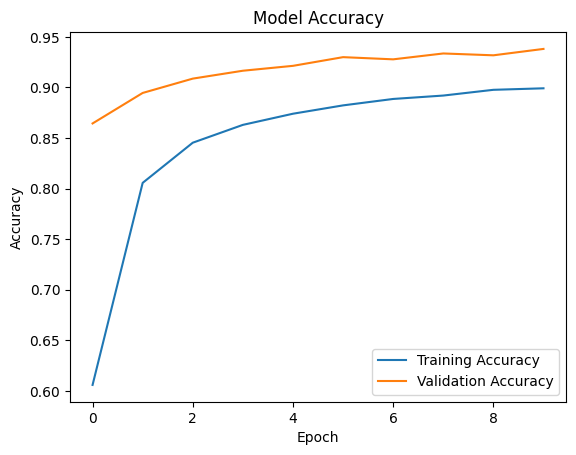

In [28]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(["Training Accuracy", "Validation Accuracy"])

plt.show()

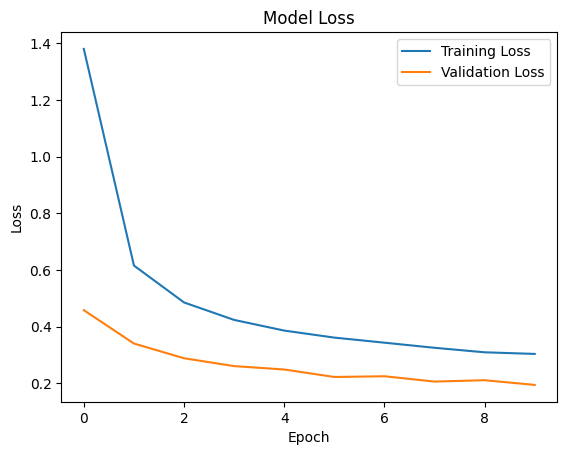

In [29]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.legend(["Training Loss", "Validation Loss"])

plt.show()

In [30]:
loss, accuracy = model.evaluate(valid_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

550/550 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.9399 - loss: 0.1911
Validation Loss: 0.19397416710853577
Validation Accuracy: 0.9381402134895325


In [31]:
predictions = model.predict(valid_data)

550/550 ━━━━━━━━━━━━━━━━━━━━ 36s 55ms/step


In [33]:
import numpy as np

predicted_classes = np.argmax(predictions, axis=1)

In [34]:
true_classes = valid_data.classes

In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_classes, predicted_classes)
print(cm)

[[ 9 14  8 ... 14  7 11]
 [16 10 11 ... 11 10 14]
 [ 5 18 10 ... 16 12 16]
 ...
 [ 9 12 13 ... 12 11 15]
 [ 9 16 21 ... 10  9 11]
 [13 15 13 ... 14  7 15]]


In [36]:
from sklearn.metrics import classification_report

class_labels = list(valid_data.class_indices.keys())

print(classification_report(true_classes, predicted_classes, target_names=class_labels))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.02      0.02      0.02       504
                                 Apple___Black_rot       0.02      0.02      0.02       497
                          Apple___Cedar_apple_rust       0.02      0.02      0.02       440
                                   Apple___healthy       0.04      0.04      0.04       502
                               Blueberry___healthy       0.04      0.04      0.04       454
          Cherry_(including_sour)___Powdery_mildew       0.03      0.03      0.03       421
                 Cherry_(including_sour)___healthy       0.01      0.02      0.02       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.03      0.03      0.03       410
                       Corn_(maize)___Common_rust_       0.02      0.02      0.02       477
               Corn_(maize)___Northern_Leaf_Blight       0.04      0.04      0.

In [38]:
import numpy as np


images, labels = next(valid_data)

test_img = images[0]
prediction = model.predict(np.expand_dims(test_img, axis=0))

predicted_class = np.argmax(prediction)

class_labels = list(train_data.class_indices.keys())

print("Predicted disease:", class_labels[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Predicted disease: Orange___Haunglongbing_(Citrus_greening)


In [39]:
# Evaluate the model
loss, accuracy = model.evaluate(valid_data)

# Project summary
print("Model: MobileNetV2 Transfer Learning")
print("Dataset: New Plant Diseases Dataset")
print("Training Epochs:", len(history.history['accuracy']))
print("Validation Accuracy:", round(accuracy*100,2), "%")
print("Validation Loss:", round(loss,4))

550/550 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - accuracy: 0.9379 - loss: 0.1931
Model: MobileNetV2 Transfer Learning
Dataset: New Plant Diseases Dataset
Training Epochs: 10
Validation Accuracy: 93.81 %
Validation Loss: 0.194


In [40]:
from google.colab import files
files.download("plant_disease_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
import json

class_labels = train_data.class_indices

with open("class_labels.json", "w") as f:
    json.dump(class_labels, f)

print("Class labels saved!")
print(class_labels)

Class labels saved!
{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_

In [43]:
files.download("class_labels.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>